In [10]:
import sklearn, pandas, numpy, matplotlib, seaborn, nltk, flask, joblib
print("All good! scikit-learn", sklearn.__version__)

All good! scikit-learn 1.9.1


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import joblib

In [14]:
df = pd.read_csv("task1_classification/Iris.csv")
df = df.drop(columns="Id")
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [16]:
X = df.drop(columns="Species")
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 120
Test samples: 30


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Predictions:", y_pred[:10])
print("Actual:     ", y_test.values[:10])

Predictions: ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor']
Actual:      <StringArray>
[    'Iris-setosa',  'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
     'Iris-setosa', 'Iris-versicolor',     'Iris-setosa',     'Iris-setosa',
  'Iris-virginica', 'Iris-versicolor']
Length: 10, dtype: str


In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print()
print(classification_report(y_test, y_pred))

Accuracy:  0.9000
Precision: 0.9024
Recall:    0.9000

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



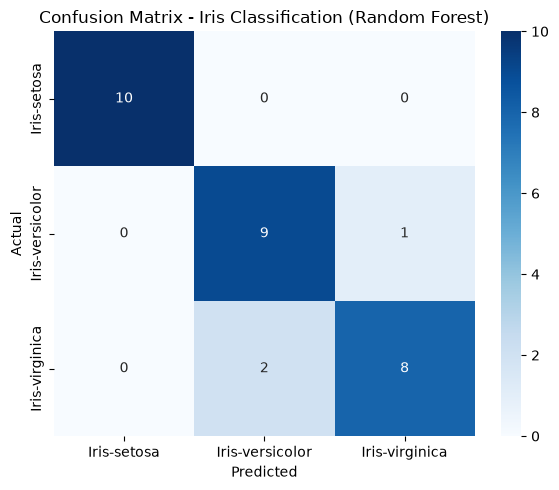

In [20]:
cm = confusion_matrix(y_test, y_pred)
labels = model.classes_

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Iris Classification (Random Forest)")
plt.tight_layout()
plt.savefig("task1_classification/confusion_matrix.png", dpi=150)
plt.show()

In [21]:
joblib.dump(model, "task1_classification/iris_model.joblib")
joblib.dump(scaler, "task1_classification/iris_scaler.joblib")
print("Saved!")

Saved!


In [22]:
print(os.listdir("task1_classification"))

['confusion_matrix.png', 'Iris.csv', 'iris_model.joblib', 'iris_scaler.joblib']


## Task 1 Summary: Iris Species Classification

**Dataset:** I used the Iris dataset downloaded from Kaggle. It has 150 flowers, each with four measurements (sepal length, sepal width, petal length, petal width), and three species: Iris-setosa, Iris-versicolor and Iris-virginica. The classes are perfectly balanced, with 50 flowers of each species.

**Preprocessing:** I separated the four measurements (inputs) from the species (target). I then split the data 80/20 into 120 training and 30 test samples, using a stratified split so each species is equally represented in both sets. The features were standardised with StandardScaler, fitted on the training data only, to avoid data leakage from the test set.

**Model choice:** I trained a Random Forest Classifier with 100 trees. It works well on small tabular datasets like this one, needs very little tuning, copes with overlapping classes, and is easy to explain because it combines the votes of many decision trees.

**Results:** On the 30 unseen test flowers, the model achieved:
- Accuracy: 90.0%
- Precision (macro average): 0.9024
- Recall (macro average): 0.9000

**Confusion matrix analysis:** Iris-setosa was classified perfectly (10 of 10). All errors happened between the other two species: one Iris-versicolor was predicted as Iris-virginica, and two Iris-virginica were predicted as Iris-versicolor. This makes sense because these two species have overlapping petal and sepal measurements, while setosa is clearly separable.

**Limitation:** The test set contains only 30 samples, so a single misclassification changes accuracy by about 3.3 percentage points. The 90% figure is therefore not a very stable estimate. Techniques like cross-validation would give a more reliable measure of performance. The dataset is also small and clean, so these results may not carry over to messier real-world data.